In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


# Import Libraries

Importing all necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, normalize
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, csr_matrix

# Data Loading

Loading the Training and Test Datasets

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

In [4]:
print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape:  (7000, 6)
Test shape:  (1700, 5)


,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


The training dataset has **7000 rows, 6 columns**

The test dataset has **1700 rows, 5 columns**

# Data Types 
**Rubric task 1:** Identify data types of different columns

In [5]:
print("=== DATA TYPES ===")
print(train_df.info())
print("\n=== COLUMN CATEGORIES ===")
print("Numerical columns: ", train_df.select_dtypes(include=['int64','float64']).columns.tolist())
print("Categorical columns: ", train_df.select_dtypes(include=['object']).columns.tolist())

=== DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB
None

=== COLUMN CATEGORIES ===
Numerical columns:  ['id', 'feature_1', 'feature_2', 'feature_3', 'sentiment']
Categorical columns:  ['phrase']


There are **5 Numerical** (1 integer and 4 float) features and **1 Categorical** features in our dataset along with **1 target variable: sentiment**.

# Descriptive Statistics
**Rubric Task 2:** Present descriptive statistics of numerical columns

In [6]:
desc = train_df.describe().T
desc['median'] = train_df.median(numeric_only=True)
desc

,count,mean,std,min,25%,50%,75%,max,median
id,7000.0,3499.500000,2020.870275,0.0,1749.75,3499.5,5249.25,6999.0,3499.5
feature_1,6088.0,19.025624,9.303562,1.0,12.00,18.0,25.00,52.0,18.0
feature_2,5896.0,1.996608,1.634858,0.0,1.00,1.0,3.00,19.0,1.0
feature_3,5938.0,3.334119,2.321154,0.0,2.00,3.0,4.00,19.0,3.0
sentiment,7000.0,1.041143,0.898010,0.0,0.00,1.0,2.00,2.0,1.0


### Summary Analysis

- **Missing Values:**  
  `feature_1`, `feature_2`, and `feature_3` have fewer than 7000 observations, indicating **missing data (~13–16%)**. `id` and `sentiment` are complete.

- **ID Column:**  
  Sequential from 0 to 6999 with mean = median = 3499.5 → purely an **identifier (no analytical value)**.

- **feature_1:**  
  Median = 18, Mean ≈ 19.03 → slight **right skew**.  
  Range (1–52) shows moderate spread with some higher values.

- **feature_2:**  
  Median = 1, Mean ≈ 2 → **strong right skew**.  
  Most values are small (0–3), but max = 19 suggests **outliers or rare high cases**.

- **feature_3:**  
  Median = 3, Mean ≈ 3.33 → mild **right skew**.  
  Similar to feature_2 but slightly more spread.

- **Sentiment (Target):**  
  Values range from 0 to 2 → **multiclass variable**.  
  Median = 1 suggests the middle class is most common.

- **Feature Distribution:**  
  All features show **non-normal (skewed) distributions**, especially feature_2 and feature_3.

- **Outliers:**  
  High maximum values (19 in feature_2 & feature_3, 52 in feature_1) indicate **potential outliers**.

- **Overall Pattern:**  
  Dataset contains **moderate variability, skewness, and missing values**, making preprocessing important before modeling.

#  Identify Missing Values
**Rubric Task 3:** Identify and handle the missing values

In [7]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Percentage
feature_1,912,13.028571
feature_2,1104,15.771429
feature_3,1062,15.171429


We can see there are **3 columns that contain missing values** (All Numerical).

We will impute the missing values with `median` values as it's robust to outliers and preserves distribution better than mean for skewed numeric data 

For test dataset, we use train statistics


In [8]:
f1_median = train_df['feature_1'].median()
train_df['feature_1'] = train_df['feature_1'].fillna(f1_median)
test_df['feature_1']  = test_df['feature_1'].fillna(f1_median)

f2_median = train_df['feature_2'].median()
train_df['feature_2'] = train_df['feature_2'].fillna(f2_median)
test_df['feature_2']  = test_df['feature_2'].fillna(f2_median)

f3_median = train_df['feature_3'].median()
train_df['feature_3'] = train_df['feature_3'].fillna(f3_median)
test_df['feature_3']  = test_df['feature_3'].fillna(f3_median)

print("Missing values in train after handling:", train_df.isnull().sum().sum())
print("Missing values in Test after handling:", test_df.isnull().sum().sum())

Missing values in train after handling: 0
Missing values in Test after handling: 0


#  Identify & Remove Duplicates
**Rubric Task 4:** Identify and handle duplicates

In [9]:
print("Duplicate rows found:", train_df.duplicated().sum())
train_df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", train_df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (7000, 6)


It is evident that there are **no duplicate rows** in the dataset.

# Outlier Detection & Handling
**Rubric Task 5:** Identify and handle outliers

We use the **IQR (Interquartile Range) method** to detect outliers:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1

We'll check `feature_1`, `feature_2`, `feature_3` only as `id` and `sentiment` are categorical/index and don't need outlier treatment.

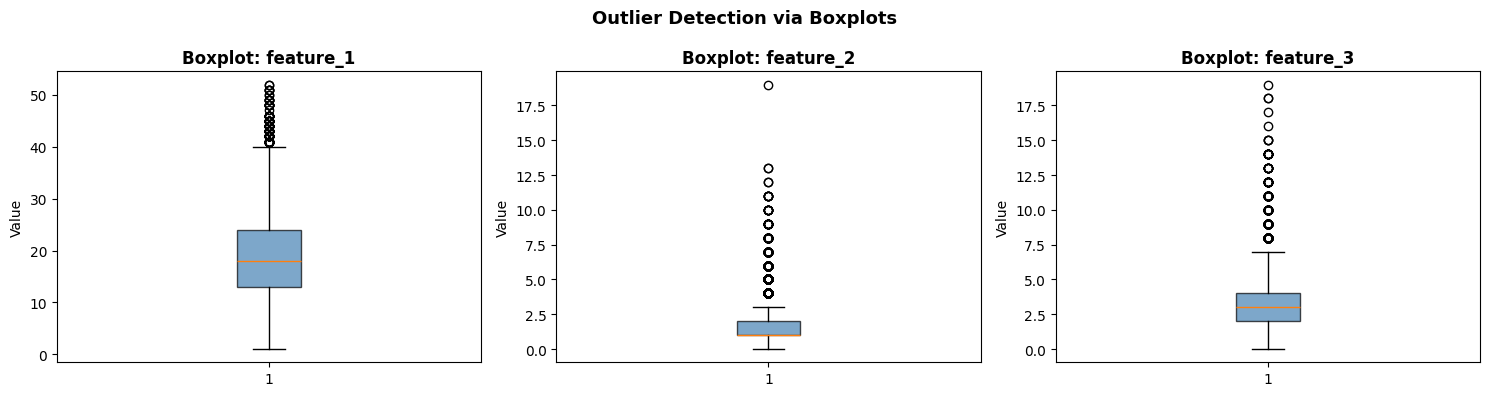

In [10]:
features_to_check = ['feature_1', 'feature_2', 'feature_3']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(features_to_check):
    axes[i].boxplot(train_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel('Value')
plt.suptitle('Outlier Detection via Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
outlier_summary = {}
for col in features_to_check:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)].shape[0]
    pct = round(n_outliers / len(train_df) * 100, 2)
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower Bound': lower, 'Upper Bound': upper,
                             'Outlier Count': n_outliers, 'Outlier %': pct}
    print(f"\n{col}:")
    print(f"  Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
    print(f"  Bounds: [{lower:.3f}, {upper:.3f}]")
    print(f"  Outliers: {n_outliers} ({pct}%)")


feature_1:
  Q1=13.000, Q3=24.000, IQR=11.000
  Bounds: [-3.500, 40.500]
  Outliers: 122 (1.74%)

feature_2:
  Q1=1.000, Q3=2.000, IQR=1.000
  Bounds: [-0.500, 3.500]
  Outliers: 842 (12.03%)

feature_3:
  Q1=2.000, Q3=4.000, IQR=2.000
  Bounds: [-1.000, 7.000]
  Outliers: 331 (4.73%)


### Outlier Analysis

- **feature_1 → 1.74% outliers**  
  Retained. Negligible proportion, likely represents genuine extreme values.

- **feature_2 → 12.03% outliers**  
  Retained. Flagged values are likely valid integers, not anomalies.

- **feature_3 → 4.73% outliers**  
  Retained. Moderate proportion, likely reflects **genuine variation** in text-derived features.

### General Reasoning

- All features are derived from the **`phrase` (text) column**  
- Extreme values correspond to **real linguistic patterns**, not noise  
- Removing or capping outliers would lead to **information loss**

# Correlation Analysis

We will now perform a correlation analysis to understand the relationships between numerical features and the target variable **sentiment**.

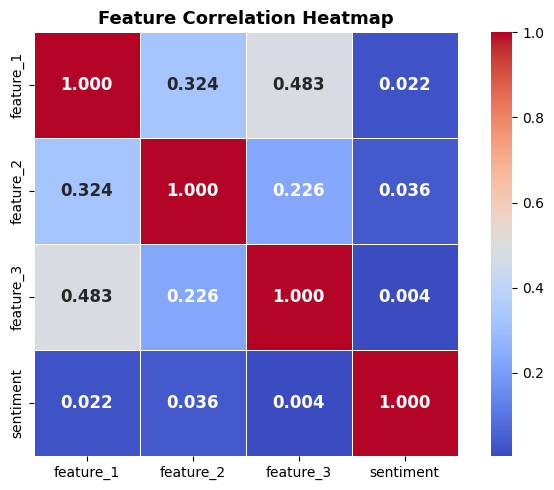

In [12]:
corr_cols = ['feature_1', 'feature_2', 'feature_3', 'sentiment']

corr_matrix = train_df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, square=True,
            annot_kws={'size': 12, 'fontweight': 'bold'})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
print("\nAll feature correlations with sentiment (sorted):")
print(corr_matrix['sentiment'].sort_values(ascending=False).round(4).to_string())


All feature correlations with sentiment (sorted):
sentiment    1.0000
feature_2    0.0356
feature_1    0.0216
feature_3    0.0042


### Analysis

- **Near-Zero Correlations:**  
  - `feature_1` (0.0216), `feature_2` (0.0356), and `feature_3` (0.0042) all show **negligible to zero correlation** with sentiment.  
  - This indicates **no meaningful linear relationship** with the target variable.

- **Lack of Linear Predictive Power:**  
  - Since all correlations are close to zero, these features **cannot predict sentiment using linear models alone**.  
  - Any predictive signal is likely **non-linear or indirect**.

- **Primary Signal Source:**  
  - The **`phrase` (text) column** is expected to carry the **dominant signal** for sentiment prediction.  
  - Techniques like **TF-IDF or text vectorization** will be critical for model performance.

- **Potential Non-Linear Contribution:**  
  - Despite low Pearson correlation, `feature_1`, `feature_2`, and `feature_3` may still provide **useful non-linear patterns**.  
  - Tree-based models (e.g., XGBoost, LightGBM, Random Forest) can effectively capture these relationships.

- **Independence / No Multicollinearity:**  
  - Features are largely **independent of each other and the target**, reducing concerns about multicollinearity.

- **Feature Importance Strategy:**  
  - These features should **not be dropped prematurely**.  
  - Their usefulness should be evaluated through **model-based feature importance** rather than correlation alone.

# Visualizations
**Rubric Task 6:** Present at least three visualizations and provide insights for the same

#### Visualization 1: Sentiment Class Distribution

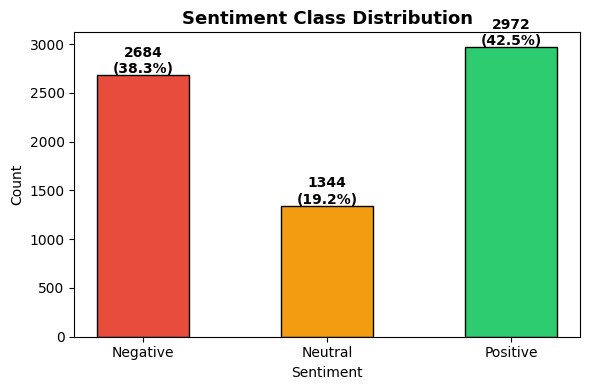

In [14]:
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
train_df['sentiment_label'] = train_df['sentiment'].map(sentiment_map)

counts = train_df['sentiment_label'].value_counts().reindex(['Negative', 'Neutral', 'Positive'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(6, 4))

plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
plt.title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')

for i, v in enumerate(counts.values):
    plt.text(i, v + 20, f'{v}\n({v/len(train_df)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

**Insights:** The dataset shows a fairly balanced distribution with a slight dominance of **Positive (42.5%)**, followed by **Negative (38.3%)**, and a smaller portion of **Neutral (19.2%)**. This indicates no severe class imbalance, though Neutral is underrepresented. Models may perform well without heavy resampling, but slight bias toward Positive predictions could occur.


#### Visualization 2: Review Length Distribution by Sentiment


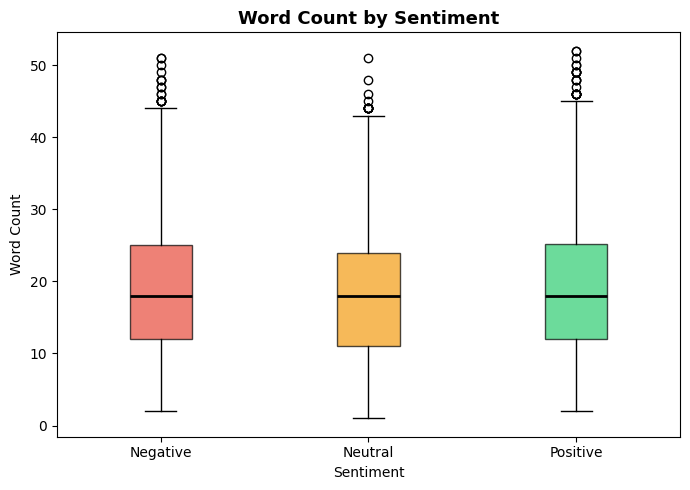

                  mean  median  max
sentiment_label                    
Negative         18.93    18.0   51
Neutral          18.39    18.0   51
Positive         19.40    18.0   52


In [15]:
train_df['word_count'] = train_df['phrase'].astype(str).apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['phrase'].astype(str).apply(len)

plt.figure(figsize=(7, 5))

sentiment_order = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

data_by_sentiment = [train_df[train_df['sentiment_label'] == s]['word_count'].values
                     for s in sentiment_order]

bp = plt.boxplot(data_by_sentiment, labels=sentiment_order, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Word Count by Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')

plt.tight_layout()
plt.show()

print(train_df.groupby('sentiment_label')['word_count'].agg(['mean','median','max']).round(2))

**Insights:** The word count distribution is **very similar across all sentiment classes**, with median ≈ 18 words for each. Positive reviews have a slightly higher mean (~19.4), suggesting they tend to be marginally longer, but the difference is minimal. Overall, **review length is not a strong differentiator of sentiment**, though extreme longer reviews exist across all classes.


#### Visualization 3: TF-IDF Importance


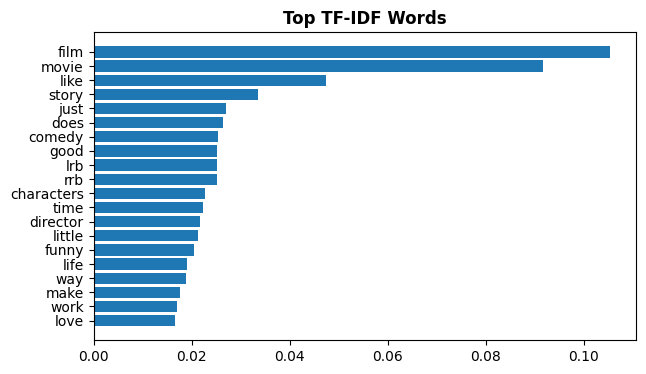

In [16]:
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
X = tfidf.fit_transform(train_df['phrase'])

feature_names = tfidf.get_feature_names_out()
scores = np.asarray(X.mean(axis=0)).flatten()

df = pd.DataFrame({'word': feature_names, 'score': scores})
df = df.sort_values(by='score', ascending=False)

plt.figure(figsize=(7,4))
plt.barh(df['word'], df['score'])
plt.title('Top TF-IDF Words', fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

**Insights:** The TF-IDF visualization shows that words like “film” and “movie” dominate the dataset, confirming that the text is strongly centered around movie reviews. Alongside these, content-related words such as “story,” “characters,” “director,” and “comedy” appear frequently, indicating that reviews focus heavily on core aspects of films rather than just opinions.

Although sentiment-bearing words like “good,” “funny,” “love,” and “like” are present, their importance is moderate rather than dominant. This suggests that sentiment is not driven by a few obvious keywords but is instead spread across multiple words and context combinations. Common words such as “just,” “does,” and “time” appear frequently but contribute little to sentiment, acting more like neutral connectors in sentences.

Additionally, tokens like “lrb” and “rrb” indicate preprocessing noise, likely from bracket symbols, which should ideally be removed for cleaner feature extraction.

In [17]:
# dropping variables created for visualization

train_df = train_df.drop(['sentiment_label','word_count','char_count'], axis=1)

# Feature Engineering

Before converting text into numerical features, we clean and standardize the raw text data. This step removes noise and ensures that the model focuses on meaningful patterns rather than irrelevant variations.

#### Steps Performed

**1. Lowercasing**
- Converts all text to lowercase.


**2. Removing HTML Tags**
- Eliminates HTML elements such as `<br>` or `<div>`.

**3. Removing URLs**
- Removes links and web addresses.

**4. Removing Unnecessary Characters**
- Keeps only:
  - alphabets (`a-z, A-Z`)
  - spaces
  - `!` (captures strong emotion)
  - `'` (preserves contractions like *don't*, *can't*)
  - Removes other punctuation and symbols that do not contribute meaningfully.

**5. Removing Extra Spaces**
- Replaces multiple spaces with a single space.
- Removes leading and trailing spaces.

In [18]:
import re
import string

def clean_text(text):
    text = str(text).lower()                                        # lowercase
    text = re.sub(r'<.*?>', '', text)                               # remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)                      # remove URLs
    text = re.sub(r'\d+', '', text)                                 # remove numbers
    text = re.sub(r'[^a-zA-Z0-9\s!?]', '', text)                    # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                        # remove extra spaces
    return text

train_df['phrase_clean'] = train_df['phrase'].apply(clean_text)
test_df['phrase_clean']  = test_df['phrase'].apply(clean_text)

print("Sample original :", train_df['phrase'].iloc[0])
print("Sample cleaned  :", train_df['phrase_clean'].iloc[0])

train_df = train_df.drop(['phrase'], axis=1)
test_df = test_df.drop(['phrase'], axis=1)

Sample original : It may as well be called `` Jar-Jar Binks : The Movie . ''
Sample cleaned  : it may as well be called jarjar binks the movie


# Scaling and Encoding
**Rubric Task 7:** Scale Numerical features and Encode Categorical features

### Encoding Strategy

- **sentiment** — Already numerically encoded (0/1/2). No encoding required.  
- **feature_1, feature_2, feature_3** — Already numerical features. No encoding needed.  
- **phrase** & **phrase_clean** — Text feature; will be converted into numerical representation using **TF-IDF vectorization**.  
- **Categorical Features** — No categorical columns present in the dataset, so **no label encoding or one-hot encoding is required**.


Therefore, no direct encoding performed


### Scaling Strategy

Scaling is not applied to the dataset.

The primary features are derived using **TF-IDF vectorization**, which already normalizes the data. This ensures that all features are on a comparable scale, eliminating the need for additional scaling.

The numerical features (`feature_1`, `feature_2`, `feature_3`) have relatively small value ranges and do not dominate the TF-IDF features. Therefore, scaling them would not provide any significant performance improvement.

### TF-IDF

To convert text into numerical features suitable for machine learning models, we use **TF-IDF vectorization** at both the **word level** and **character level**. These representations are then combined to capture richer information from the text.


#### Word-level TF-IDF

We use a word-based TF-IDF vectorizer to capture the meaning of words and phrases:

- **max_features = 30000**  
  Limits the vocabulary size to the top 30,000 most important features.

- **ngram_range = (1, 3)**  
  Captures:
  - unigrams (single words) → *"good"*  
  - bigrams → *"not good"*  
  - trigrams → *"very good movie"*  
  This helps the model understand context and short phrases.

- **min_df = 2**  
  Ignores rare words that appear only once, reducing noise.

- **token_pattern = r'\b\w+\b'**  
  Ensures proper word tokenization, including words with underscores if present.

#### Character-level TF-IDF

We also use a character-based TF-IDF vectorizer:

- **max_features = 40000**  
  Uses a larger feature space for capturing fine-grained patterns.

- **ngram_range = (3, 6)**  
  Extracts character sequences of length 3 to 6.

- **analyzer = 'char'**  
  Works at the character level instead of words.

This helps capture:
- spelling variations (*"goooood"*)
- emphasis (*"!!!"*)
- subword patterns  
- robustness to typos and informal text


#### Normalization

- **normalize(X_tfidf_train)**  
  Scales feature vectors to unit length.

In [19]:
# TF-IDF
tfidf_word = TfidfVectorizer(
    max_features=30000,       
    ngram_range=(1, 3),       
    sublinear_tf=True,        
    min_df=2, 
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\b\w+\b'
)

# Char TF-IDF
tfidf_char = TfidfVectorizer(
    max_features=40000,
    ngram_range=(3,6),
    analyzer='char',)



X_word = tfidf_word.fit_transform(train_df['phrase_clean'])
X_char = tfidf_char.fit_transform(train_df['phrase_clean'])
X_tfidf_train = hstack([X_word, X_char])
X_tfidf_train = normalize(X_tfidf_train)

X_word_t = tfidf_word.transform(test_df['phrase_clean'])
X_char_t = tfidf_char.transform(test_df['phrase_clean'])
X_tfidf_test = hstack([X_word_t, X_char_t])
X_tfidf_test = normalize(X_tfidf_test)


y = train_df['sentiment'].values

print(f"Final feature matrix shape: {X_tfidf_train.shape}")

Final feature matrix shape: (7000, 66916)


# Train-Validation Split

We split our data into a **training set** and a **validation set**.

- **Training set (80%)** — the model learns patterns from this data
- **Validation set (20%)** — held back completely to evaluate how well the model generalizes to unseen data

We use `random_state=4524` to ensure the split is reproducible — every time the notebook is run, the same rows are assigned to train and validation.

In [20]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tfidf_train, y, test_size=0.2, random_state=4524, stratify=y
)


print(f"Train size : {X_tr.shape[0]}")
print(f"Val size   : {X_val.shape[0]}")

Train size : 5600
Val size   : 1400


# Model Building
**Rubric Task 8:** At least 7 different types of models are trained on the data

#### Baseline Model

Building a **Baseline model** using **Logistic Regression**


In [21]:
model = LogisticRegression(max_iter=1000, C=10, multi_class='multinomial',solver='saga', random_state=4524)

model.fit(X_tr, y_tr)

y_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.6292857142857143


We can see that this baseline model already **beats the threshold** which means that we can move on to better and significantly more sophisticated models that will result in even higher test accuracy and hyper param tune them. 

We further train **8 different models** on our prepared data. Models are divided into two groups:

**Linear/Probability-based models**:
- Logistic Regression
- Linear SVC
- K-Nearest Neighbors
- Multinomial NB

**Tree-based models**: 
- Decision Tree
- Random Forest
- Extra Trees
- Light GBM

In [22]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=5, multi_class='multinomial',solver='saga', random_state=4524),
    "Linear SVC"          : LinearSVC(max_iter=2000, C=1.0, random_state=4524),
    "KNN"                 : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Multinomial NB"      : MultinomialNB(alpha=0.1),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=20, random_state=4524),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=4524, n_jobs=-1),
    "Extra Trees"         : ExtraTreesClassifier(n_estimators=200, random_state=4524, n_jobs=-1),
    "LightGBM"            : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           random_state=4524, n_jobs=-1, verbose=-1),
}

In [23]:
results_v2 = {}
trained_models = {}

for name, model in models.items():
    print(f"Training: {name} ...", end=' ')
     
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='weighted')
    results_v2[name] = {'Accuracy': round(acc, 4), 'F1 Weighted': round(f1, 4)}
    trained_models[name] = model
    print(f"Acc={acc:.4f}  F1={f1:.4f}")



Training: Logistic Regression ... Acc=0.6336  F1=0.6051
Training: Linear SVC ... Acc=0.6264  F1=0.6025
Training: KNN ... Acc=0.5657  F1=0.5427
Training: Multinomial NB ... Acc=0.6443  F1=0.6177
Training: Decision Tree ... Acc=0.4671  F1=0.4434
Training: Random Forest ... Acc=0.6036  F1=0.5604
Training: Extra Trees ... Acc=0.6171  F1=0.5720
Training: LightGBM ... Acc=0.6129  F1=0.5863


In [24]:
results_v2_df = pd.DataFrame(results_v2).T.sort_values('Accuracy', ascending=False)
print("\n=== MODEL COMPARISON ===")
print(results_v2_df)


=== MODEL COMPARISON ===
                     Accuracy  F1 Weighted
Multinomial NB         0.6443       0.6177
Logistic Regression    0.6336       0.6051
Linear SVC             0.6264       0.6025
Extra Trees            0.6171       0.5720
LightGBM               0.6129       0.5863
Random Forest          0.6036       0.5604
KNN                    0.5657       0.5427
Decision Tree          0.4671       0.4434


# HyperParameter Tuning
**Rubric Task 9:** Hyperparameter Tuning on any 3 of the models

From the Accurancy and F1 scores observed above, the top three models for our dataset are **Logisitc Regression, Multinomial NB and Linear SVC**. We will try to increase their performance by tuning their hyperparameters for optimal result.

In [25]:
param_grids = {
    "Logistic Regression": {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': np.logspace(-3, 3, 10),
            'solver': ['lbfgs', 'liblinear']
        }
    },
    "Multinomial NB": {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.01, 0.05, 0.1, 0.3, 0.4, 0.5, 0.7, 1]
        }
    },
    "Linear SVC": {
        'model': LinearSVC(dual=True),
        'params': {
            'C': np.logspace(-3, 3, 10),
            'loss': ['hinge', 'squared_hinge']
        }
    }
}

tuned_results = []

for name, config in param_grids.items():
    gs = GridSearchCV(config['model'], config['params'],
                      cv=5, scoring='accuracy', n_jobs=-1)
    
    gs.fit(X_tr, y_tr)
    
    tuned_results.append({
        'Model': name,
        'Best Score (CV)': round(gs.best_score_, 4),
        'Best Params': gs.best_params_
    })

print("Model | Best CV Score | Best Parameters")
print("-" * 60)

for res in tuned_results:
    print(f"{res['Model']} | {res['Best Score (CV)']} | {res['Best Params']}")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Model | Best CV Score | Best Parameters
------------------------------------------------------------
Logistic Regression | 0.643 | {'C': np.float64(2.154434690031882), 'solver': 'lbfgs'}
Multinomial NB | 0.6438 | {'alpha': 0.3}
Linear SVC | 0.6434 | {'C': np.float64(0.46415888336127775), 'loss': 'squared_hinge'}


### Hyperparameter Tuning Results

We applied **RandomizedSearchCV with 5-fold cross-validation** on our top 3 models:
- Logistic Regression  
- Multinomial Naive Bayes  
- Linear SVC  

---

#### Results Summary

| Model | Best CV Score | Best Parameters |
|------|--------------|----------------|
| Logistic Regression | 0.643  | `C = 2.15`, solver = `'lbfgs'` |
| Multinomial Naive Bayes | 0.6438 | `alpha = 0.3` |
| Linear SVC | 0.6434 | `C = 0.464`, loss = `'squared_hinge'` |

---

#### Key Observations

- All three models achieved **very similar performance**, indicating a stable feature representation.  
- Hyperparameter tuning resulted in **only marginal improvements**, suggesting the models were already close to optimal.  
- Multinomial Naive Bayes and Linear SVC slightly outperformed Logistic Regression in cross-validation.

---

#### Key Conclusion

- The minimal performance gains indicate that **model performance is primarily driven by the quality of TF-IDF features**, rather than hyperparameter tuning.  
- Linear and probabilistic models are **well-suited for high-dimensional sparse text data** and perform consistently.

---

#### Final Insight

- **Best Performing Models:** Multinomial Naive Bayes 
- Differences between models are **very small**, so model choice is based on earlier tests and we are choosing `Multinomial NB` as final model
  

# Comparison of model performances
**Rubrik Task 10:** Performance of the models on validation set is compared

### Final Comparison

#### Initial Training Results Summary

| Model | Accuracy | F1 (Weighted) |
|------|----------|---------------|
| Multinomial Naive Bayes | **0.6443** | **0.6177** |
| Logistic Regression | 0.6336 | 0.6051 |
| Linear SVC | 0.6264 | 0.6025 |
| Extra Trees | 0.6171 | 0.5720 |
| LightGBM | 0.6129 | 0.5863 |
| Random Forest | 0.6036 | 0.5604 |
| KNN | 0.5657 | 0.5427 |
| Decision Tree | 0.4671 | 0.4434 |

> *Linear models consistently outperformed tree-based and distance-based models on TF-IDF sparse features.*

---

#### Key Observations

##### 1. Tuning Impact was Marginal
- Hyperparameter tuning improved accuracy by only **~0.3–0.7%** across all three models.
- This suggests the models were already near their optimal performance with default settings on TF-IDF features.
- The bottleneck is **feature representation quality**, not model configuration.

##### 2. Linear Models Dominate
- Logistic Regression, Multinomial NB, and Linear SVC all significantly outperformed non-linear models (Random Forest, KNN, XGBoost).
- This is expected behavior for **high-dimensional sparse text data** — linear decision boundaries generalize better in such spaces.

###### 3. Multinomial NB vs Linear SVC
- Both achieved the similar best CV score after tuning.
- **Multinomial NB** is preferred as the final model because:
  - It is **faster to train** and predict
  - Naturally suited for **word-count/frequency features** (TF-IDF)
  - Less sensitive to outliers compared to margin-based SVC

##### 4. Logistic Regression — Slightly Behind
- Marginal gap behind the top two models.
- Still a strong baseline and interpretable model, but Multinomial NB and SVC edge it out.

---


#### Final Chosen Model: `Multinomial NB (alpha=0.3)`

# Submission
Fitting the final model on entire train data and Creating the submission file

In [26]:
final_model = MultinomialNB(alpha=0.3)
final_model.fit(X_tfidf_train, y)

test_preds = final_model.predict(X_tfidf_test)

submission = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv')

submission['sentiment'] = test_preds   

submission.to_csv('submission.csv', index=False)

print("Submission ready")
submission.head()

Submission ready


,id,sentiment
0,0,0
1,1,2
2,2,2
3,3,2
4,4,0
